In [1]:
# ============================================
# Stage 0: Setup
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import auth
auth.authenticate_user()

print("Authenticated with Google.")

Authenticated with Google.


### Data Source Note

The preferred modeling file is `structured/datasets/listings_llm.csv`, but that file is stored in Mark's private Google Cloud Storage bucket and my account does not currently have read access. For this first modeling pass, I am using the latest `preds.csv` artifact from the GitHub `results` folder because it still contains structured listing fields and actual prices. Once Mark shares the original `listings_llm.csv` file, this loading cell should be replaced with the cleaner source file.

In [4]:
# ============================================
# Stage 0: Clone Mark's GitHub Repo
# ============================================

import os
import shutil
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_URL = "https://github.com/OPIM5512-mdk23002/myscrapers-mdk23002.git"
REPO_DIR = "myscrapers-mdk23002"

if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

!git clone $REPO_URL

RESULTS_DIR = os.path.join(REPO_DIR, "results")

pred_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*-preds.csv")))

print("Prediction files found:", len(pred_files))
print("Latest prediction file:", pred_files[-1])

Cloning into 'myscrapers-mdk23002'...
remote: Enumerating objects: 3713, done.
remote: Total 3713 (delta 0), reused 0 (delta 0), pack-reused 3713 (from 2)
Receiving objects: 100% (3713/3713), 46.79 MiB | 28.65 MiB/s, done.
Resolving deltas: 100% (2192/2192), done.
Prediction files found: 404
Latest prediction file: myscrapers-mdk23002/results/2026050115-preds.csv


In [5]:
# ============================================
# Stage 0: Load Latest Prediction Artifact
# ============================================

df = pd.read_csv(pred_files[-1])

print("Dataset shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Dataset shape: (261, 17)


,post_id,scraped_at,make,model,year,mileage,price,transmission,drivetrain,fuel_type,engine_cylinders,condition,color,body_type,title_status,actual_price,pred_price
0,7928537369,2026-05-01T04:00:14Z,Chevrolet,Suburban,2016,98804.0,8500.0,automatic,4wd,gasoline,8.0,like new,NaN,suv,clean,8500.0,13760.28
1,7929611533,2026-05-01T04:00:14Z,Honda,Crv,2004,200000.0,1600.0,automatic,NaN,gasoline,NaN,good,NaN,suv,clean,1600.0,7289.64
2,7929782270,2026-05-01T04:00:14Z,Hyundai,Kona,2019,145143.0,8975.0,automatic,4wd,gasoline,4.0,NaN,Gray,suv,clean,8975.0,13643.81
3,7930464233,2026-05-01T04:00:14Z,Toyota,Rav4,2013,125603.0,13885.0,automatic,4wd,gasoline,4.0,NaN,Green,suv,clean,13885.0,9948.35
4,7930464360,2026-05-01T04:00:14Z,Ford,Super Duty F-350,2015,264719.0,16900.0,automatic,4wd,diesel,8.0,NaN,NaN,truck,clean,16900.0,24562.91


['post_id', 'scraped_at', 'make', 'model', 'year', 'mileage', 'price', 'transmission', 'drivetrain', 'fuel_type', 'engine_cylinders', 'condition', 'color', 'body_type', 'title_status', 'actual_price', 'pred_price']


# Stage 1: Create Price Tier Target

In [6]:
df_model = df.copy()

# Use cleaned actual_price if available, otherwise clean price manually
if "actual_price" in df_model.columns:
    df_model["price_num"] = pd.to_numeric(df_model["actual_price"], errors="coerce")
else:
    df_model["price_num"] = (
        df_model["price"]
        .astype(str)
        .str.replace(r"[^\d.]+", "", regex=True)
        .str.strip()
    )
    df_model["price_num"] = pd.to_numeric(df_model["price_num"], errors="coerce")

# Drop rows without usable target
df_model = df_model.dropna(subset=["price_num"])

# Remove obvious invalid/extreme prices
df_model = df_model[df_model["price_num"] > 500]
df_model = df_model[df_model["price_num"] < 100000]

# Create three balanced price tiers
df_model["price_tier"] = pd.qcut(
    df_model["price_num"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Shape after target cleaning:", df_model.shape)

tier_counts = df_model["price_tier"].value_counts().sort_index()
display(tier_counts)

Shape after target cleaning: (253, 19)


,count
price_tier,
low,84
medium,84
high,85


# Stage 2: Create Clean Structured Modeling Dataset

In [7]:
# ============================================
# Stage 2: Create Clean Structured Modeling Dataset
# ============================================

def clean_numeric(series):
    return (
        series
        .astype(str)
        .str.replace(r"[^\d.]+", "", regex=True)
        .str.strip()
        .replace("", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )

# Clean numeric columns
df_model["year_num"] = clean_numeric(df_model["year"])
df_model["mileage_num"] = clean_numeric(df_model["mileage"])

if "engine_cylinders" in df_model.columns:
    df_model["engine_cylinders_num"] = clean_numeric(df_model["engine_cylinders"])

# Engineer simple vehicle features
df_model["vehicle_age"] = 2026 - df_model["year_num"]
df_model["miles_per_year"] = df_model["mileage_num"] / df_model["vehicle_age"].replace(0, np.nan)

# Structured features from Mark's existing pipeline
candidate_features = [
    "year_num",
    "mileage_num",
    "vehicle_age",
    "miles_per_year",
    "engine_cylinders_num",
    "make",
    "model",
    "transmission",
    "drivetrain",
    "fuel_type",
    "condition",
    "color",
    "body_type",
    "title_status"
]

structured_features = [col for col in candidate_features if col in df_model.columns]

keep_cols = ["post_id", "scraped_at", "price_num", "price_tier"] + structured_features
keep_cols = [col for col in keep_cols if col in df_model.columns]

df_structured = df_model[keep_cols].copy()

print("Structured modeling dataframe shape:", df_structured.shape)
print("\nStructured features:")
print(structured_features)

display(df_structured.head())

Structured modeling dataframe shape: (253, 18)

Structured features:
['year_num', 'mileage_num', 'vehicle_age', 'miles_per_year', 'engine_cylinders_num', 'make', 'model', 'transmission', 'drivetrain', 'fuel_type', 'condition', 'color', 'body_type', 'title_status']


,post_id,scraped_at,price_num,price_tier,year_num,mileage_num,vehicle_age,miles_per_year,engine_cylinders_num,make,model,transmission,drivetrain,fuel_type,condition,color,body_type,title_status
0,7928537369,2026-05-01T04:00:14Z,8500.0,medium,2016,98804.0,10,9880.400000,8.0,Chevrolet,Suburban,automatic,4wd,gasoline,like new,NaN,suv,clean
1,7929611533,2026-05-01T04:00:14Z,1600.0,low,2004,200000.0,22,9090.909091,NaN,Honda,Crv,automatic,NaN,gasoline,good,NaN,suv,clean
2,7929782270,2026-05-01T04:00:14Z,8975.0,medium,2019,145143.0,7,20734.714286,4.0,Hyundai,Kona,automatic,4wd,gasoline,NaN,Gray,suv,clean
3,7930464233,2026-05-01T04:00:14Z,13885.0,high,2013,125603.0,13,9661.769231,4.0,Toyota,Rav4,automatic,4wd,gasoline,NaN,Green,suv,clean
4,7930464360,2026-05-01T04:00:14Z,16900.0,high,2015,264719.0,11,24065.363636,8.0,Ford,Super Duty F-350,automatic,4wd,diesel,NaN,NaN,truck,clean


In [8]:
# ============================================
# Stage 2: Missing Value Summary
# ============================================

missing_summary = df_structured.isna().sum().sort_values(ascending=False)

display(missing_summary)

print("Rows:", df_structured.shape[0])
print("Columns:", df_structured.shape[1])

,0
condition,59
color,40
drivetrain,38
engine_cylinders_num,25
body_type,21
miles_per_year,2
fuel_type,2
transmission,1
scraped_at,0
post_id,0


Rows: 253
Columns: 18


# Stage 3: Split Data Once

In [9]:
# ============================================
# Stage 3: Split Data Once
# ============================================

from sklearn.model_selection import train_test_split

X = df_structured[structured_features].copy()
y = df_structured["price_tier"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain class counts:")
display(y_train.value_counts().sort_index())

print("\nTest class counts:")
display(y_test.value_counts().sort_index())

print("\nTrain class distribution:")
display(y_train.value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
display(y_test.value_counts(normalize=True).sort_index())

X_train shape: (202, 14)
X_test shape: (51, 14)

Train class counts:


,count
price_tier,
low,67
medium,67
high,68



Test class counts:


,count
price_tier,
low,17
medium,17
high,17



Train class distribution:


,proportion
price_tier,
low,0.331683
medium,0.331683
high,0.336634



Test class distribution:


,proportion
price_tier,
low,0.333333
medium,0.333333
high,0.333333


In [10]:
# ============================================
# Stage 3: Sanity Check for Feature Leakage
# ============================================

leakage_cols = [col for col in X.columns if "price" in col.lower()]

print("Columns with 'price' in the feature set:")
print(leakage_cols)

Columns with 'price' in the feature set:
[]


# Stage 4: Structured Baseline Preprocessing
### Structured Baseline Model

This first model uses only structured listing fields, such as year, mileage, make, model, fuel type, condition, and LLM-extracted vehicle attributes. I am intentionally leaving out listing text and images here so this model can act as the baseline. If later text or image models perform better, we can more clearly say those unstructured inputs added useful signal.

In [11]:
# ============================================
# Stage 4: Structured Baseline Preprocessing
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)
print("Class labels:", label_encoder.classes_)

Numeric features: ['year_num', 'mileage_num', 'vehicle_age', 'miles_per_year', 'engine_cylinders_num']
Categorical features: ['make', 'model', 'transmission', 'drivetrain', 'fuel_type', 'condition', 'color', 'body_type', 'title_status']
Processed X_train shape: (202, 202)
Processed X_test shape: (51, 202)
Class labels: ['high' 'low' 'medium']


In [12]:
# ============================================
# Stage 4: Build Dense Neural Network Baseline
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

num_classes = len(label_encoder.classes_)
input_dim = X_train_processed.shape[1]

model_structured = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model_structured.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_structured.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        12,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,171 (59.26 KB)

 Trainable params: 15,171 (59.26 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ============================================
# Stage 4: Train Structured Baseline
# ============================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_structured = model_structured.fit(
    X_train_processed,
    y_train_encoded,
    validation_split=0.20,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.3230 - loss: 1.0964 - val_accuracy: 0.2927 - val_loss: 1.0741
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4472 - loss: 1.0471 - val_accuracy: 0.3171 - val_loss: 1.0519
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5652 - loss: 0.9806 - val_accuracy: 0.4146 - val_loss: 1.0359
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5466 - loss: 0.9439 - val_accuracy: 0.4146 - val_loss: 1.0163
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6087 - loss: 0.8950 - val_accuracy: 0.4634 - val_loss: 0.9981
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6584 - loss: 0.8387 - val_accuracy: 0.4634 - val_loss: 0.9760
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6770 - loss: 0.7742 - val_accuracy: 0.4878 - val_loss: 0.9370
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7143 - loss: 0.7305 - val_accuracy: 0.5366 - v

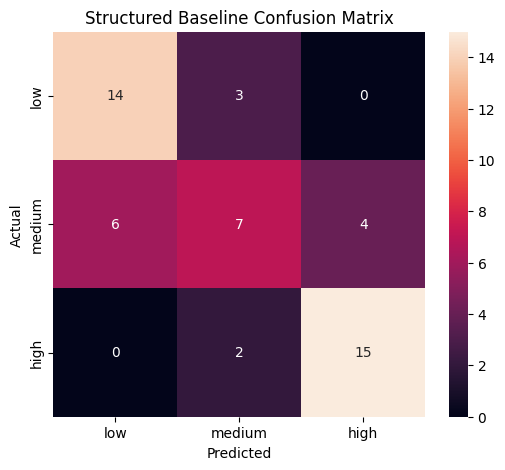

In [16]:
# ============================================
# Cleaner Confusion Matrix Order
# ============================================

from sklearn.metrics import confusion_matrix

ordered_labels = ["low", "medium", "high"]

# Convert encoded predictions back to labels
y_test_labels = label_encoder.inverse_transform(y_test_encoded)
y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

cm_ordered = confusion_matrix(
    y_test_labels,
    y_pred_labels,
    labels=ordered_labels
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_ordered,
    annot=True,
    fmt="d",
    xticklabels=ordered_labels,
    yticklabels=ordered_labels
)
plt.title("Structured Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
# ============================================
# Save Structured Baseline Results
# ============================================

model_results = []

model_results.append({
    "model_name": "Structured Dense Baseline",
    "input_type": "Structured listing fields",
    "accuracy": accuracy,
    "weighted_f1": weighted_f1,
    "main_takeaway": "Strong on low and high tiers, weaker on medium tier."
})

results_df = pd.DataFrame(model_results)
display(results_df)

,model_name,input_type,accuracy,weighted_f1,main_takeaway
0,Structured Dense Baseline,Structured listing fields,0.705882,0.69095,"Strong on low and high tiers, weaker on medium..."
